In [1]:
from results_utils import compute_results, plot_mean_std_for_model, load_results_paths, compute_metric, boxplot_for_model, plot_manual_boxplot_for_model
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

In [2]:
# metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# # metrics = ["norm_error_rate", "norm_cross_entropy"]
# bootstrap = 0
# random_state = 42
# df_results = compute_results(metrics, bootstrap, random_state)

In [3]:
# plot_mean_std_for_model(df_results, "lm_tinyllama", metrics[:-1], width = 0.5, err=False, stat="median")

In [4]:
metrics = ["norm_error_rate", "norm_cross_entropy", "ece"]#, "cal_loss_bias", "norm_min_calibration_bias"]
# metrics = ["norm_error_rate", "norm_cross_entropy"]
bootstrap = 0
random_state = 42

if os.path.exists(f"results_{bootstrap}_{random_state}.csv"):
    df = pd.read_csv(f"results_{bootstrap}_{random_state}.csv", index_col=False)
else:
    df = compute_results(metrics, bootstrap, random_state)
    df.to_csv(f"results_{bootstrap}_{random_state}.csv", index=False)
# df = compute_results(metrics, bootstrap, random_state)
df.loc[:,[c for c in df.columns if ":" not in c ]]

KeyError: 'base_method'

In [7]:
# df_lora_cal = df.loc[
#     (df["base_method"] == "lora_xval") & \
#     ((df["cal_method"] == "no_calibration") | \
#      (df["cal_method"] == "affine_scalar")  | \
#      (df["cal_method"] == "temp_scaling") | \
#      (df["cal_method"] == "bias_only")),
#     ["dataset", "size", "base_method", "cal_method", "norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# ]
# df_results = df.loc[(df["base_method"] != "lora_xval") | (df["cal_method"] != "no_calibration"), :]

# df_results = df.loc[(df["base_method"] != "lora_xval") & (df["cal_method"] != "affine_scalar_no_es"), :]
# df_results = df_results.loc[
#     (df_results["cal_method"] != "affine_scalar_train_on_val") |
#     ((df_results["cal_method"] == "affine_scalar_train_on_val") & \
#     (df_results["size"] >= 16)),
# :]

df_results = df
# df_lora_cal

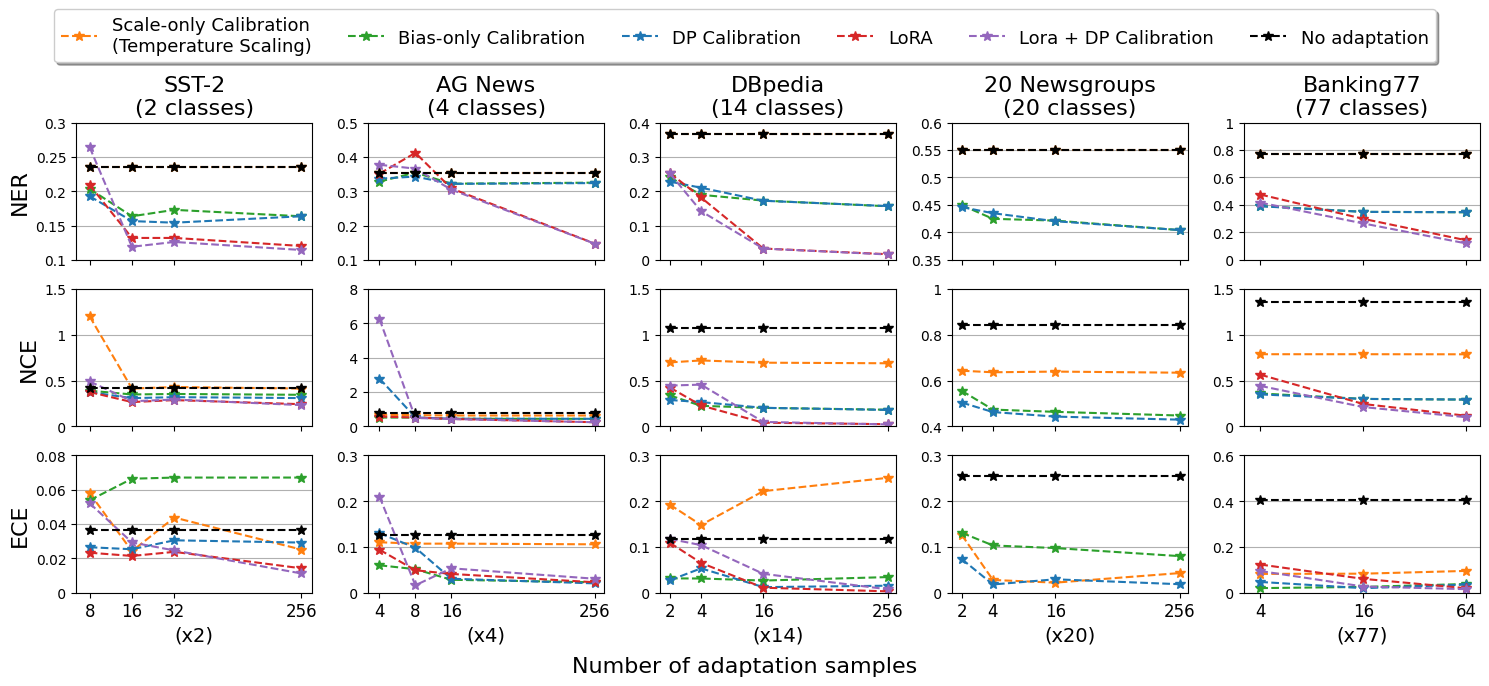

In [8]:
# plot_results_for_model(df_results, "lm_tinyllama", ["norm_error_rate", "norm_cross_entropy", "cal_loss_bias", "ece"], width = 0.5)
plot_mean_std_for_model(df_results, "lm_phi3", metrics, width = 0.5, err=False, stat="median")

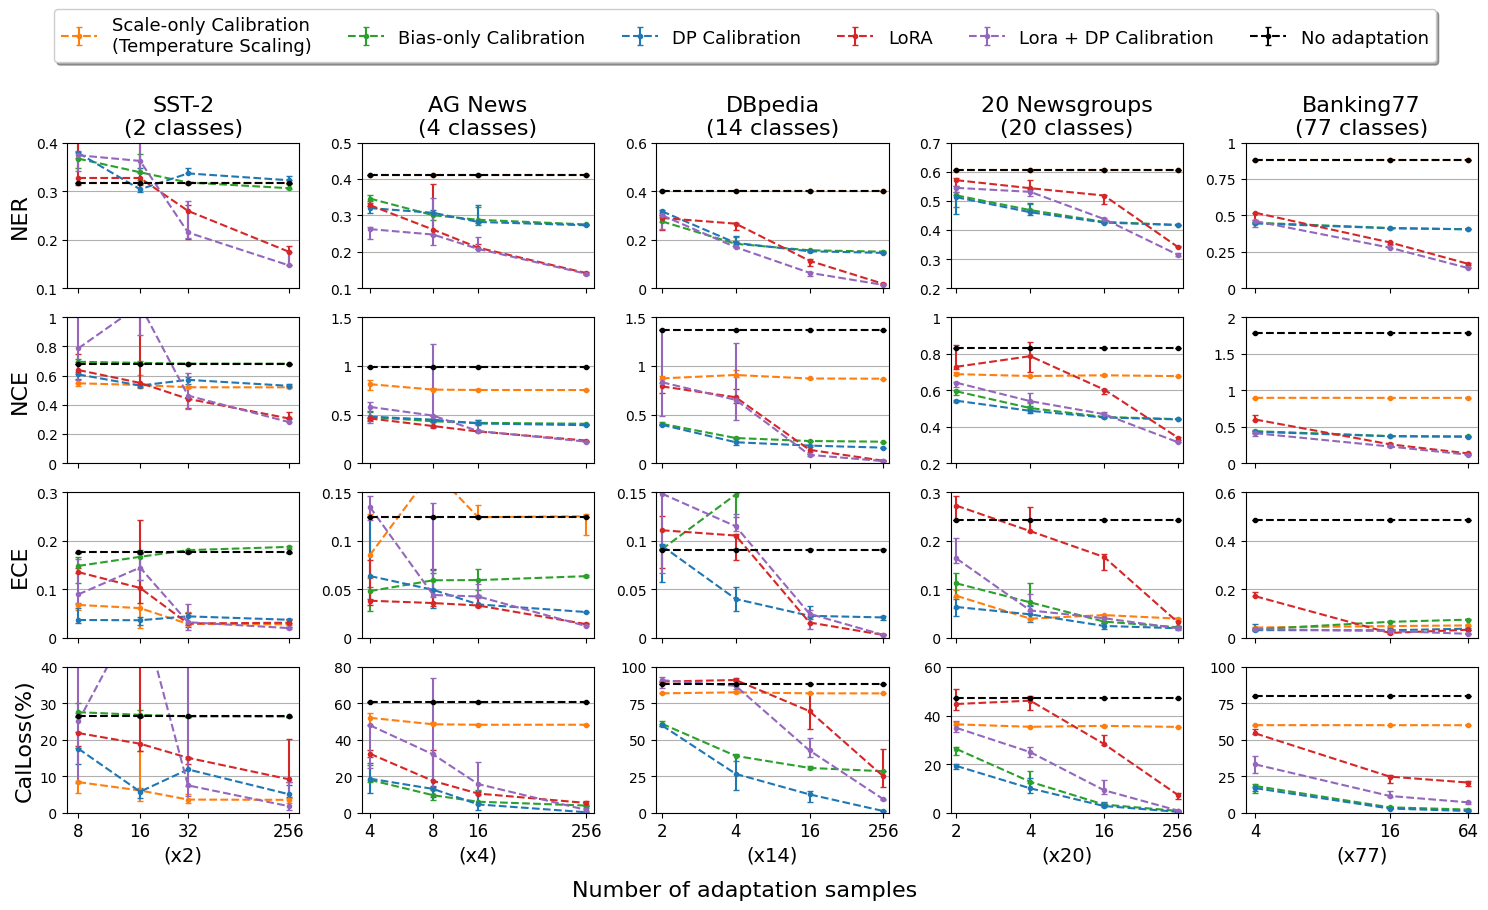

In [8]:
plot_manual_boxplot_for_model(df_results, "lm_tinyllama", metrics[:-1], width = 0.5)

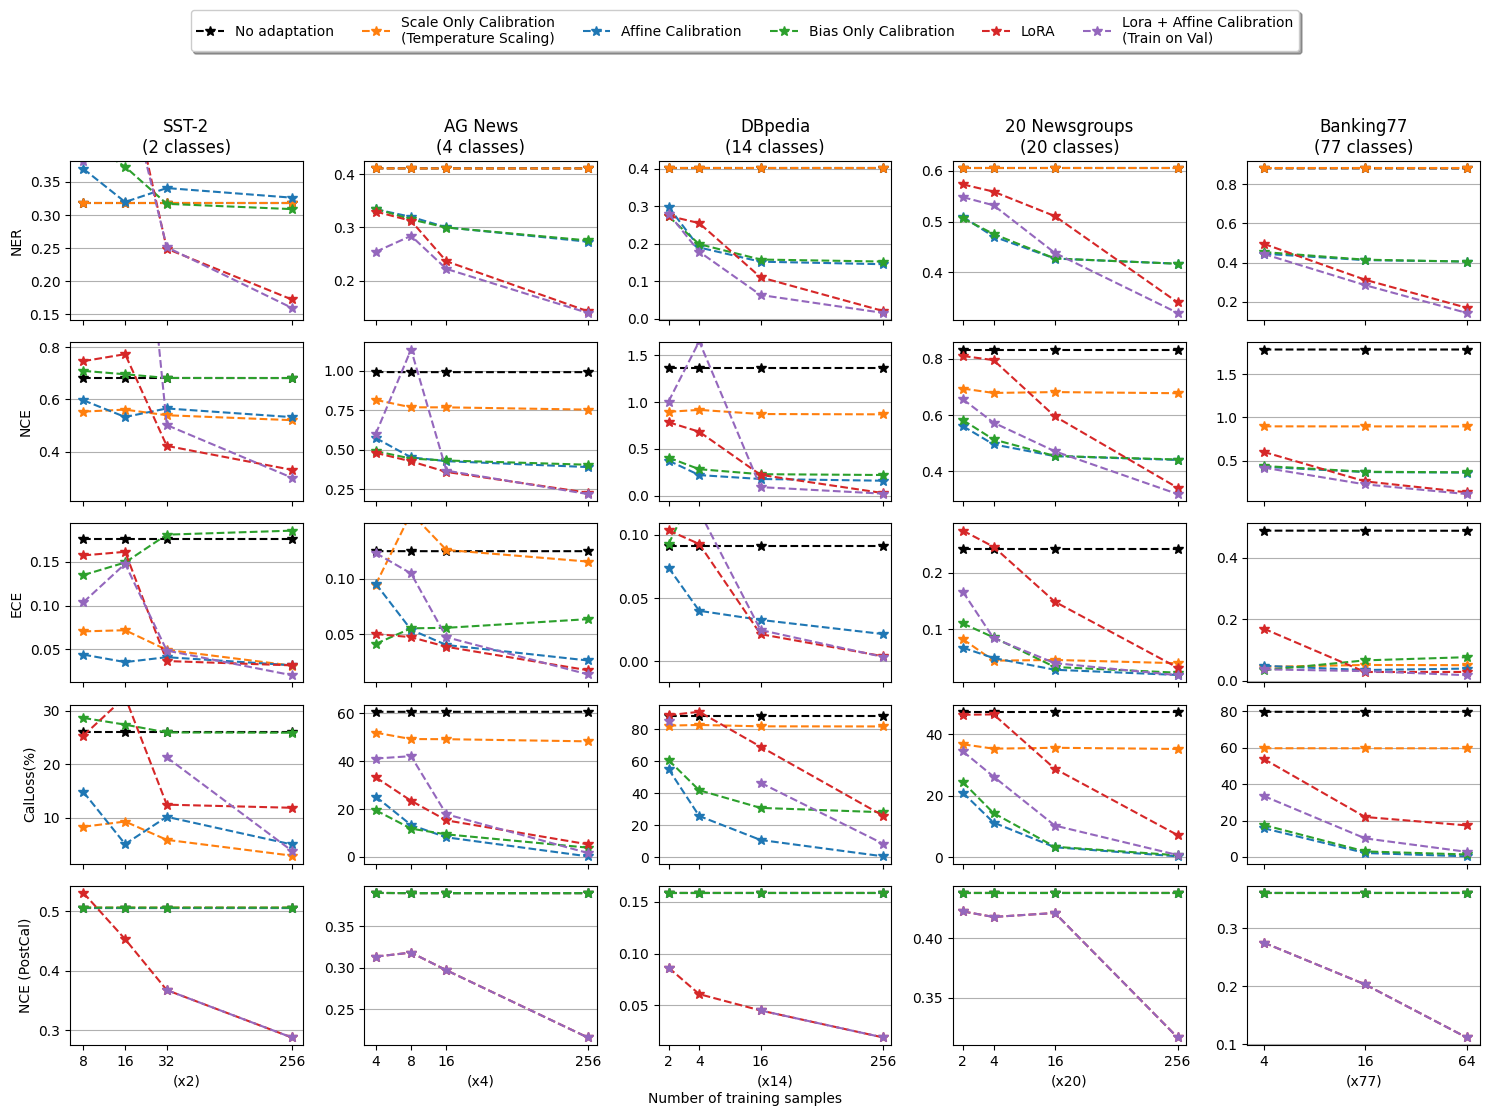

In [6]:
plot_mean_std_for_model(df_results, "lm_tinyllama", metrics, width = 0.5, err=False, stat="mean")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5 and the array at index 2 has size 4

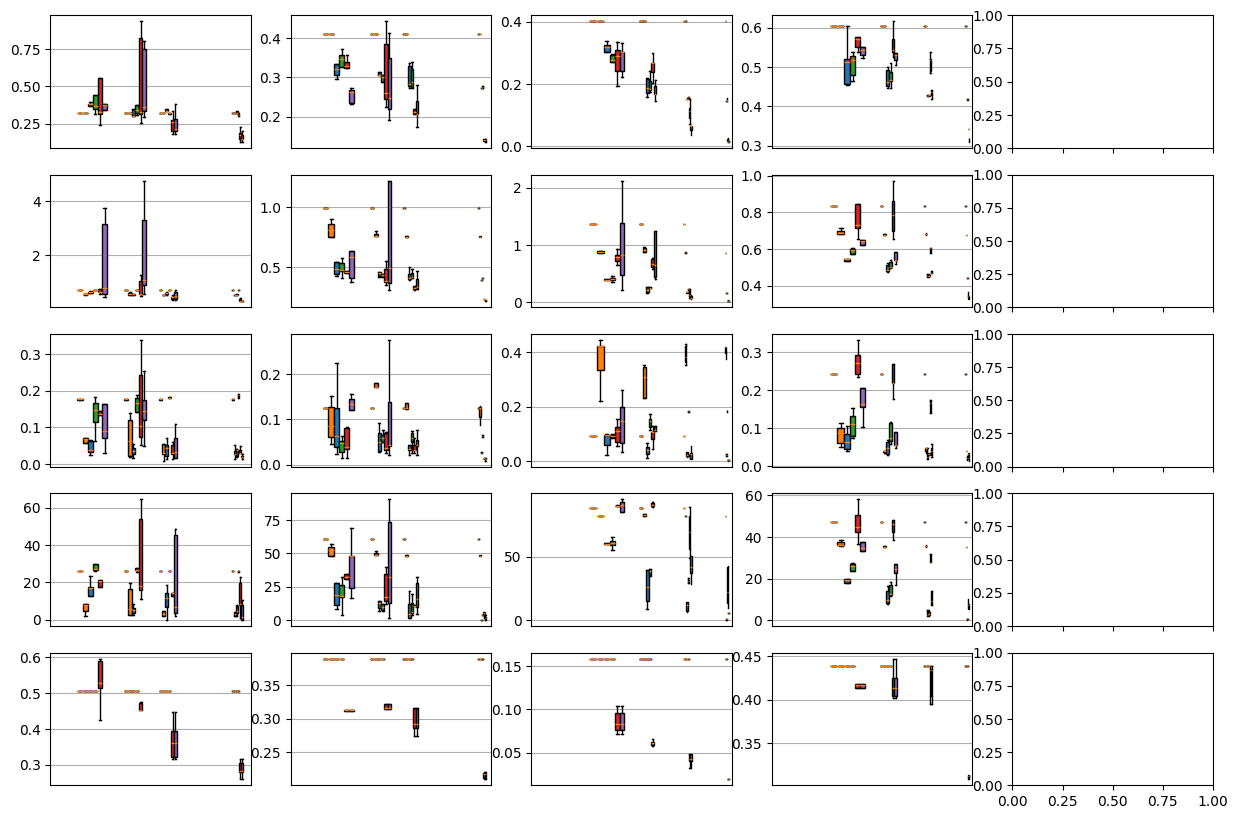

In [7]:
boxplot_for_model(df_results, "lm_tinyllama", metrics, width = 0.5)

In [ ]:
# df_results[df_results["dataset"] == "dbpedia"]
for idx, group in df[df["cal_method"] == "affine_scalar_train_on_val"].groupby(["dataset", "size"]):
    print(group.loc[:,["dataset", "size", "cal_loss_bias"]])
    print()

KeyError: "['cal_loss_bias'] not in index"